In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,f1_score,recall_score,classification_report,confusion_matrix,roc_auc_score,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Load the breast cancer dataset for this problems
X , y = load_breast_cancer(return_X_y=True)

In [3]:
# Now we will split the data into training and testing set 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42 )

In [4]:
# Now we will use Logistic Regression and Decision Tree Classifier to do Classification Metric Analysis
# Basically we all this to determine which algorithm is the best performing . 

# Loading and Instantiating models
log = LogisticRegression(max_iter=5000)
clf = DecisionTreeClassifier()
# We are using this as both are models to do classification type problems

In [5]:
# Fit both the models 
log.fit(X_train,y_train)
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [6]:
# Store predictions from both the models.
y_pred_lor = log.predict(X_test)
y_pred_clf = clf.predict(X_test)

In [7]:
# Now lets compare both the models scores
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Accuracy score :  {accuracy_score(y_test,y_pred_lor)}  {accuracy_score(y_test,y_pred_clf)}')
print(f' Precision score : {precision_score(y_test,y_pred_lor)}  {precision_score(y_test,y_pred_clf)}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor)}  {recall_score(y_test,y_pred_clf)}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor)}  {f1_score(y_test,y_pred_clf)}')

 	 	   Scores for LR       Scores for CLF 
 Accuracy score :  0.9766081871345029  0.9298245614035088
 Precision score : 0.9814814814814815  0.9528301886792453
 Recall score :    0.9814814814814815  0.9351851851851852
 F1 score :        0.9814814814814815  0.9439252336448598


In [8]:
# Compring the confusion matrix and the TP,TN,FP,FN values
#   00 = True Positives - The actual and predicted values for correct data from models matched
#   11 = True Negatives - The actual and predicted values for incorrect data from models matched
#   01 = False Negatives - The actual labels were not predicted by the model (Did not predict something which was correct,need to be predicted)
#   10 = False Positive - The predictions made by model were incorrect (labelled incorrectly )
conf1 = pd.DataFrame(confusion_matrix(y_test,y_pred_lor))
conf2 = pd.DataFrame(confusion_matrix(y_test,y_pred_clf))

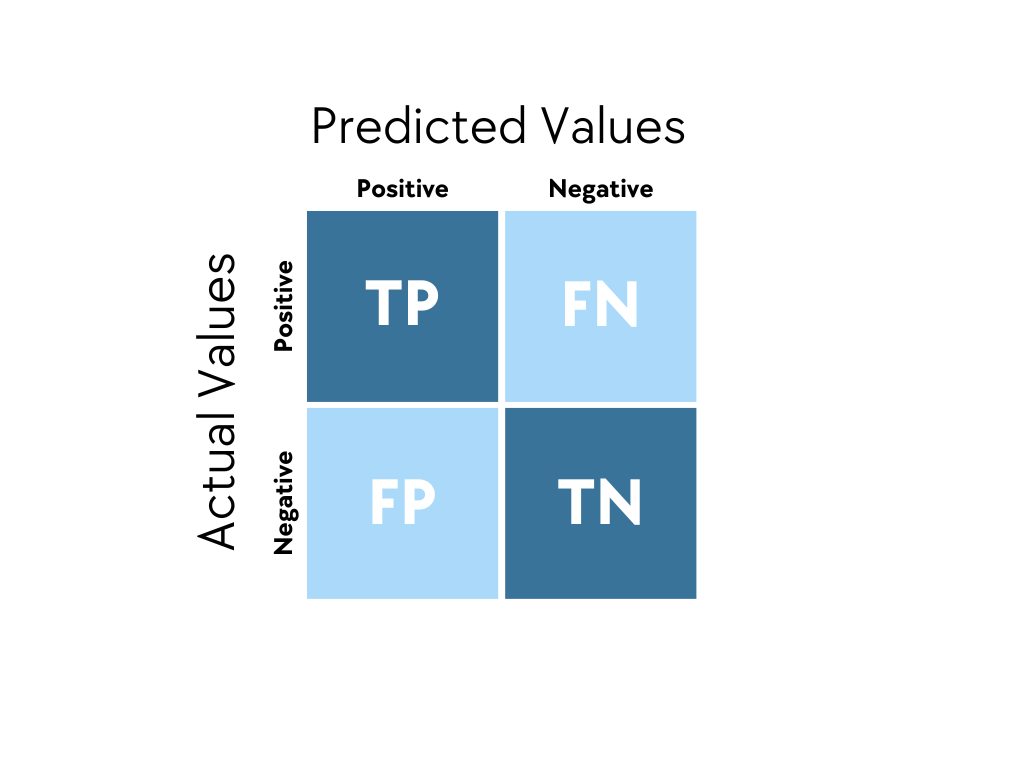

In [9]:
conf1 

,0,1
0,61,2
1,2,106


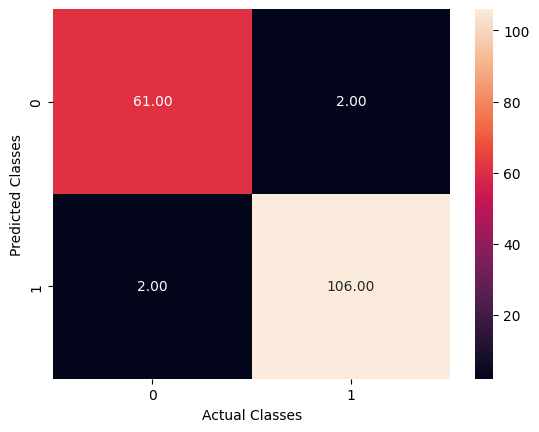

In [23]:
sns.heatmap(data = conf1 , annot = True , fmt = '.2f') 
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [10]:
conf2

,0,1
0,58,5
1,7,101


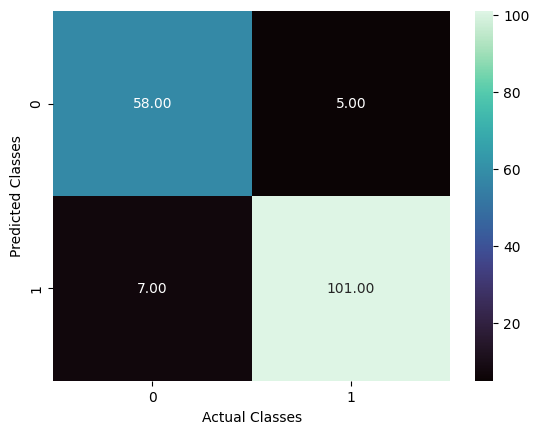

In [26]:
sns.heatmap(data = conf2 , annot = True , fmt = '.2f' , cmap = 'mako') 
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [11]:
# Note this same can be done on multiple columns for multiple labels 
# There we will calculate all the scores for one label by label

In [12]:
# Also to calculate scores for each there are two methods :
# First by using weights
# Second by using average which is the default 

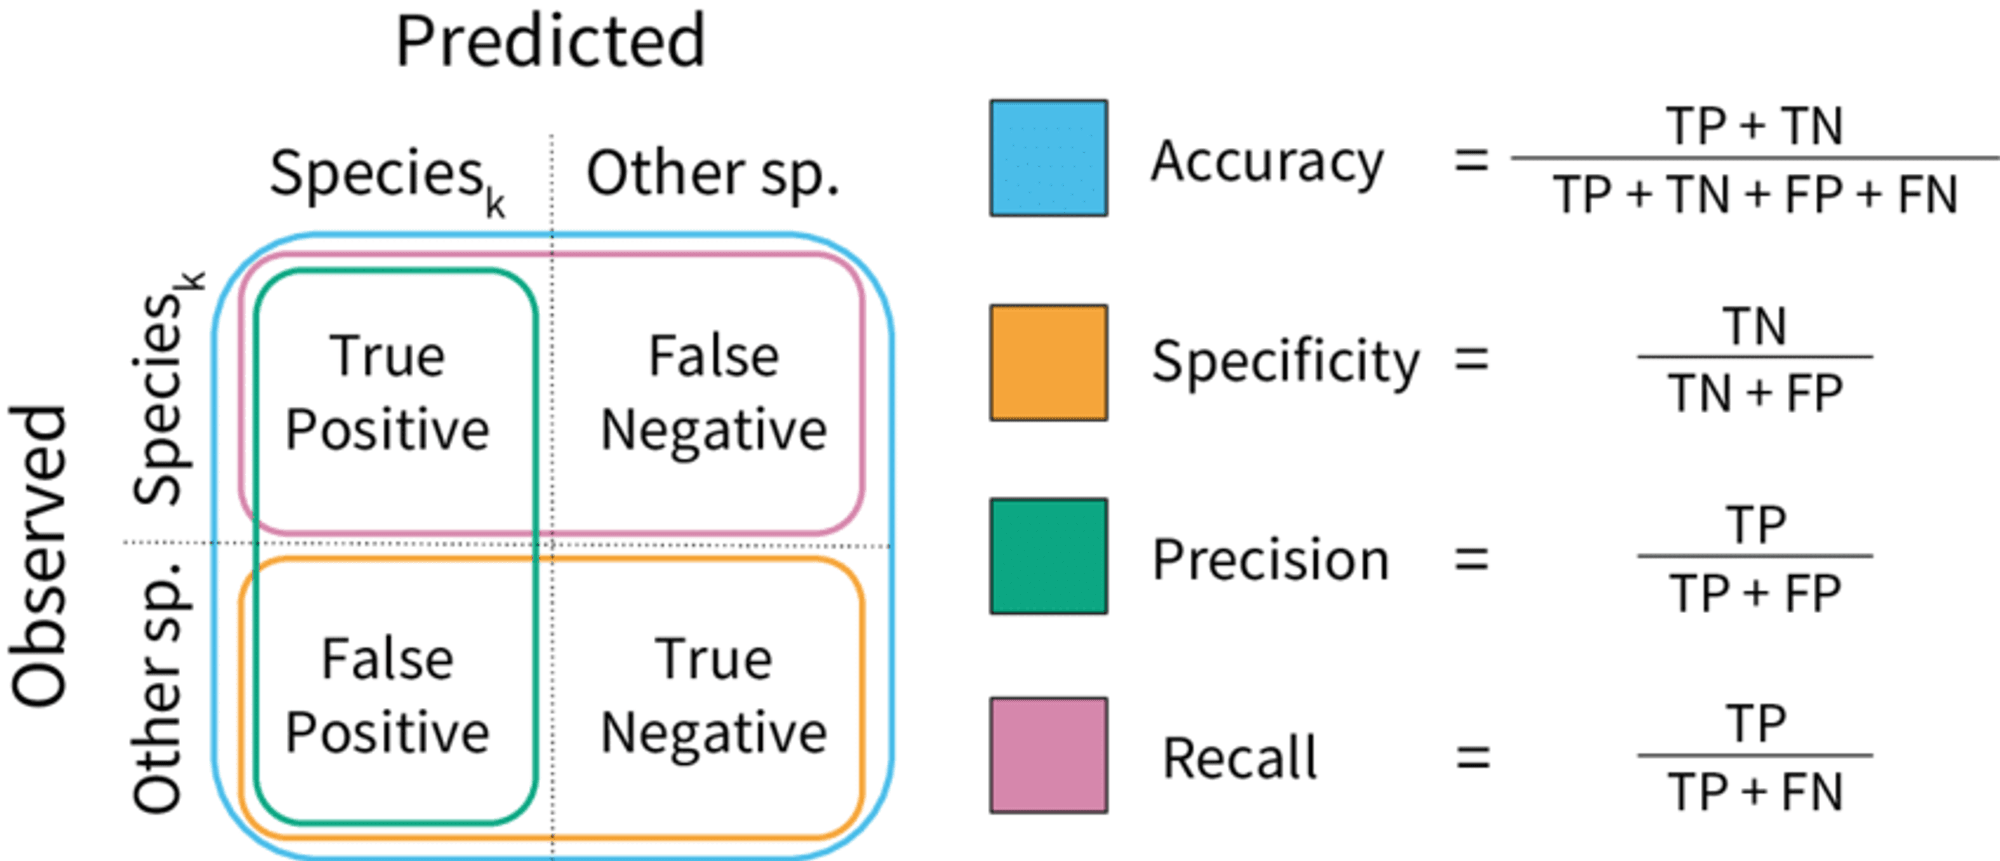

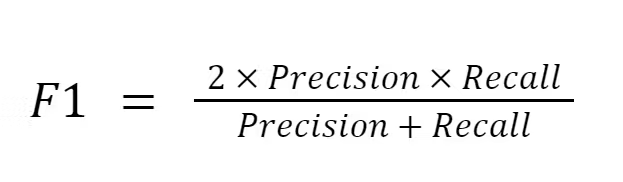

In [13]:
# This is when we do average is None so we get the score for each 
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Precision score : {precision_score(y_test,y_pred_lor,average=None)}  {precision_score(y_test,y_pred_clf,average=None)}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor,average=None)}  {recall_score(y_test,y_pred_clf,average=None)}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor,average=None)}  {f1_score(y_test,y_pred_clf,average=None)}')
# As you can see we had two labels so 2 columns 
# Same applicable for multiple columns (Also confusion matrix)

 	 	   Scores for LR       Scores for CLF 
 Precision score : [0.96825397 0.98148148]  [0.89230769 0.95283019]
 Recall score :    [0.96825397 0.98148148]  [0.92063492 0.93518519]
 F1 score :        [0.96825397 0.98148148]  [0.90625    0.94392523]


In [14]:
# This is when we do average is 'macro' / weighted average so we get the score for each 
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Precision score : {precision_score(y_test,y_pred_lor,average='macro')}  {precision_score(y_test,y_pred_clf,average='macro')}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor,average='macro')}  {recall_score(y_test,y_pred_clf,average='macro')}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor,average='macro')}  {f1_score(y_test,y_pred_clf,average='macro')}')

 	 	   Scores for LR       Scores for CLF 
 Precision score : 0.9748677248677249  0.9225689404934688
 Recall score :    0.9748677248677249  0.9279100529100529
 F1 score :        0.9748677248677249  0.9250876168224299


In [28]:
print(classification_report(y_test,y_pred_lor))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [29]:
print(classification_report(y_test,y_pred_clf))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91        63
           1       0.95      0.94      0.94       108

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171



In [30]:
# Now we will talk about some other advanced metrics 

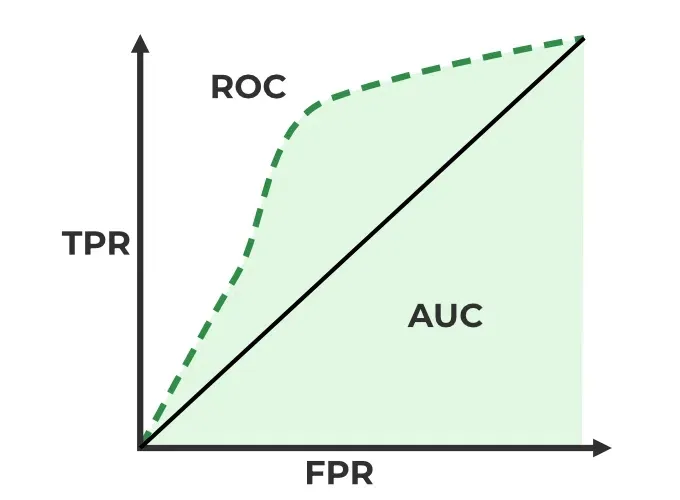
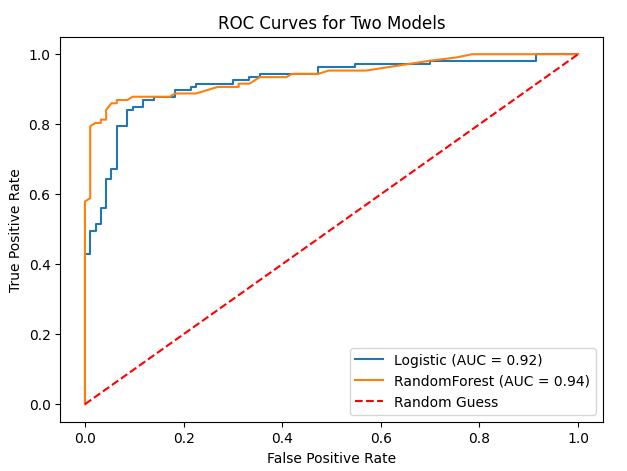
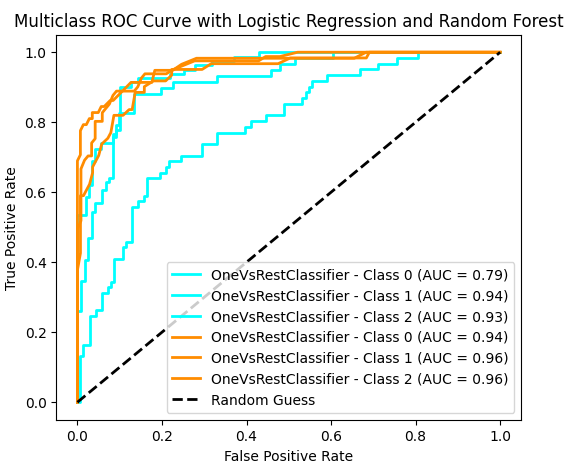

In [36]:
roc_auc_score(y_test,log.predict_proba(X_test)[:,1])

0.9976484420928865

In [38]:
roc_auc_score(y_test,clf.predict_proba(X_test)[:,1])

0.9279100529100529

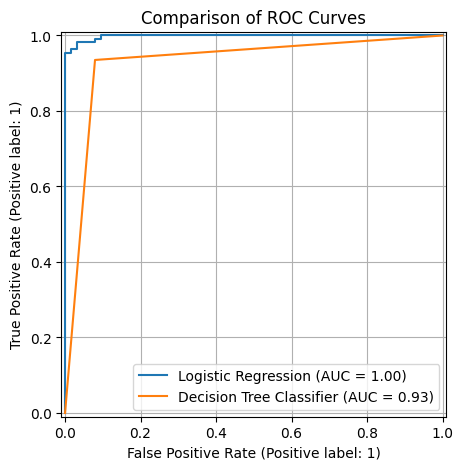

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(9, 5))

# 2. Plot Model 1 (e.g., Logistic Regression)
RocCurveDisplay.from_estimator(log, X_test, y_test, ax=ax, name='Logistic Regression')

# 3. Plot Model 2 (e.g., Random Forest)
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name='Decision Tree Classifier')

# 4. Final touches
plt.title('Comparison of ROC Curves')
plt.grid(True)
plt.show()
